# Tutorial 5: ML Model
## Introducción
Usaremos *Pima Indians Diabetes* dataset. Vamos a explorar:
1. **Cross-Validation (CV)**
2. **Feature Selection Methods**: SelectKBest, RFE, and SelectFromModel
3. **Hyperparameter Tuning con CV**: GridSearchCV,  RandomizedSearchCV
4. **PyCaret**: AutoML con CV y HT

More information about Kaggle: https://www.kaggle.com/

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Cargar datasets
dset_trn = pd.read_csv('pima_train.csv')
dset_tst = pd.read_csv('pima_test.csv')

print('Forma del set de entrenamiento:', dset_trn.shape)
print('Forma del set de test:', dset_tst.shape)

Forma del set de entrenamiento: (538, 10)
Forma del set de test: (230, 9)


## Pre procesamiento  de datos

Datos faltantes??

In [3]:
# Verificar valores faltantes
print('Missing values (proportions):')
print(dset_trn.isna().sum() / dset_trn.shape[0])

# Eliminar Insulin (demasiados valores faltantes)
dset_trn.drop(columns='Insulin', inplace=True)
dset_tst.drop(columns='Insulin', inplace=True)

# Preparar datos
X_train = dset_trn.drop(columns=['Id','Outcome']).to_numpy()
X_test = dset_tst.drop(columns='Id').to_numpy()
y_train = dset_trn['Outcome'].to_numpy()

# Imputar valores faltantes
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='mean').fit(X_train)
X_train = imp.transform(X_train)
X_test = imp.transform(X_test)

# Escalar datos
from sklearn import preprocessing
mm_scaler = preprocessing.StandardScaler()
X_train = mm_scaler.fit_transform(X_train)
X_test = mm_scaler.transform(X_test)

print('\nForma de datos procesados:')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')

Missing values (proportions):
Pregnancies                 0.000000
Glucose                     0.007435
BloodPressure               0.048327
SkinThickness               0.301115
Insulin                     0.494424
BMI                         0.014870
DiabetesPedigreeFunction    0.000000
Age                         0.000000
Outcome                     0.000000
Id                          0.000000
dtype: float64

Forma de datos procesados:
X_train: (538, 7), y_train: (538,)
X_test: (230, 7)


---
# PARTE 1: ENTENDIENDO CROSS-VALIDATION (CV)

## ¿Qué es Cross-Validation?

Cross-Validation (CV) es una técnica para evaluar la capacidad de generalización de un modelo.
En lugar de usar un único train/test split, dividimos el set de entrenamiento en múltiples 'folds' (pliegues).

### ¿Por qué es importante para hyperparameter tuning?

**Sin CV (incorrecto):**
```
Train Set → Tune hyperparameters → Evaluate en Train Set
                                    ↑ DATA LEAKAGE!
```

**Con CV (correcto):**
```
Train Set → Split en 5 folds
  - Fold 1: Train en folds 2-5, evalúa en fold 1
  - Fold 2: Train en folds 1,3-5, evalúa en fold 2
  - ... etc
  → Mejor estimación de rendimiento real
```

## Ejemplo 1: CV sin Hyperparameter Tuning

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Crear modelo con hyperparametros fijos
lr = LogisticRegression(max_iter=1000, C=1.0)

# Usar CV para evaluar el modelo
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train, y_train, cv=skf, scoring='roc_auc')

print('Puntuaciones AUC para cada fold:')
print(cv_scores)
print(f'\nAUC promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Puntuaciones AUC para cada fold:
[0.86390977 0.80977444 0.84774436 0.81045004 0.81960336]

AUC promedio: 0.8303 (+/- 0.0217)


## Ejemplo 2: CV CON Hyperparameter Tuning 

In [5]:
from sklearn.model_selection import GridSearchCV

# Definir grilla de hiperparámetros
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# GridSearchCV realiza CV automáticamente
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Mejores hiperparámetros:')
print(grid_search.best_params_)
print(f'Mejor puntuación CV AUC: {grid_search.best_score_:.4f}')
print(f'\nResultados de validación cruzada:')
cv_results = pd.DataFrame(grid_search.cv_results_)
print(cv_results[['param_C', 'mean_test_score', 'std_test_score']].head(10))

Mejores hiperparámetros:
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor puntuación CV AUC: 0.8312

Resultados de validación cruzada:
  param_C  mean_test_score  std_test_score
0   0.001         0.819209        0.028634
1    0.01         0.825338        0.027927
2     0.1         0.831174        0.033552
3       1         0.830109        0.034994
4      10         0.830640        0.035751
5     100         0.830640        0.035751


## Ejemplo 3: Visualizando CV 

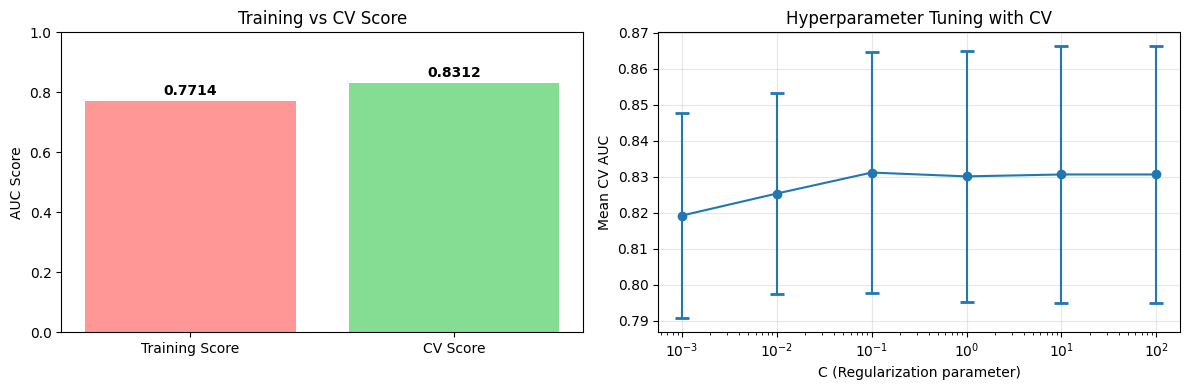

In [6]:
# Comparación: Puntuación de entrenamiento vs Puntuación CV
best_model = grid_search.best_estimator_

# Puntuación en el set de entrenamiento COMPLETO
train_score = best_model.score(X_train, y_train)

# CV score 
cv_score = grid_search.best_score_

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Entrenamiento vs Puntuación CV
scores = [train_score, cv_score]
labels = ['Training Score', 'CV Score']
colors = ['#ff6b6b', '#51cf66']
axes[0].bar(labels, scores, color=colors, alpha=0.7)
axes[0].set_ylabel('AUC Score')
axes[0].set_title('Training vs CV Score')
axes[0].set_ylim([0, 1])
for i, v in enumerate(scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Gráfico 2: Puntuaciones CV por hiperparámetro C
cv_results_df = pd.DataFrame(grid_search.cv_results_)
axes[1].errorbar(cv_results_df['param_C'], 
                 cv_results_df['mean_test_score'],
                 yerr=cv_results_df['std_test_score'],
                 marker='o', capsize=5, capthick=2)
axes[1].set_xlabel('C (Regularization parameter)')
axes[1].set_ylabel('Mean CV AUC')
axes[1].set_title('Hyperparameter Tuning with CV')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



---
# PARTE 2: SELECCIÓN DE ATRIBUTOS (Feature Selection)

## ¿Por qué seleccionar atributos?
- Reducir overfitting
- Mejorar eficiencia computacional
- Interpretabilidad
- Pueden mejorar el rendimiento del modelo

## Métodos a explorar:
1. **SelectKBest**: Selecciona los K atributos con mejor score estadístico
2. **RFE (Recursive Feature Elimination)**: Elimina atributos recursivamente
3. **SelectFromModel**: Selecciona atributos basado en importancia del modelo

## 1. SelectKBest

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

# SelectKBest con criterio f_classif (Valor F de ANOVA)
selector_kbest = SelectKBest(score_func=f_classif, k=4)
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
X_test_kbest = selector_kbest.transform(X_test)

# Ver cuáles atributos fueron seleccionados
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                 'BMI', 'DiabetesPedigreeFunction', 'Age']
selected_mask = selector_kbest.get_support()
selected_features = [f for f, selected in zip(feature_names, selected_mask) if selected]

print('Resultados de SelectKBest:')
print(f'Features seleccionados: {selected_features}')
print(f'Forma: {X_train_kbest.shape[0]} muestras, {X_train_kbest.shape[1]} features')

# Mostrar puntuaciones de cada atributo
scores_df = pd.DataFrame({
    'Feature': feature_names,
    'F-Score': selector_kbest.scores_,
    'Selected': selected_mask
}).sort_values('F-Score', ascending=False)

print('\nPuntuaciones de características:')
print(scores_df)

Resultados de SelectKBest:
Features seleccionados: ['Glucose', 'SkinThickness', 'BMI', 'Age']
Forma: 538 muestras, 4 features

Puntuaciones de características:
                    Feature     F-Score  Selected
1                   Glucose  154.610154      True
4                       BMI   75.159962      True
3             SkinThickness   33.840630      True
6                       Age   25.345796      True
0               Pregnancies   19.818466     False
5  DiabetesPedigreeFunction   17.205409     False
2             BloodPressure   17.034327     False


## 2. Recursive Feature Elimination (RFE)

In [8]:
from sklearn.feature_selection import RFE

# RFE: Elimina recursivamente atributos usando un estimador
estimator = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=estimator, n_features_to_select=4, step=1)

X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

# Ver cuáles atributos fueron seleccionados
selected_rfe = [f for f, selected in zip(feature_names, rfe.support_) if selected]

print('Resultados de RFE:')
print(f'Selected features: {selected_rfe}')
print(f'Shape: {X_train_rfe.shape[0]} samples, {X_train_rfe.shape[1]} features')

# Mostrar ranking
rfe_df = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('Ranking')

print('\nRanking de características (1 = seleccionado):')
print(rfe_df)

Resultados de RFE:
Selected features: ['Pregnancies', 'Glucose', 'BMI', 'DiabetesPedigreeFunction']
Shape: 538 samples, 4 features

Ranking de características (1 = seleccionado):
                    Feature  Ranking  Selected
0               Pregnancies        1      True
1                   Glucose        1      True
4                       BMI        1      True
5  DiabetesPedigreeFunction        1      True
6                       Age        2     False
2             BloodPressure        3     False
3             SkinThickness        4     False


## 3. SelectFromModel (basado en importancia del modelo)

In [9]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# SelectFromModel usa importancia de features de un modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
selector_model = SelectFromModel(rf, prefit=False, threshold='median')

X_train_sfm = selector_model.fit_transform(X_train, y_train)
X_test_sfm = selector_model.transform(X_test)

# Ver cuáles atributos fueron seleccionados
selected_sfm = [f for f, selected in zip(feature_names, selector_model.get_support()) if selected]

print('Resultados de SelectFromModel:')
print(f'Selected features: {selected_sfm}')
print(f'Shape: {X_train_sfm.shape[0]} samples, {X_train_sfm.shape[1]} features')

# Mostrar importancia de características
rf_fitted = selector_model.estimator_
sfm_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_fitted.feature_importances_,
    'Selected': selector_model.get_support()
}).sort_values('Importance', ascending=False)

print('\nImportancia de características (Random Forest):')
print(sfm_df)

Resultados de SelectFromModel:
Selected features: ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Shape: 538 samples, 4 features

Importancia de características (Random Forest):
                    Feature  Importance  Selected
1                   Glucose    0.278726      True
4                       BMI    0.182618      True
6                       Age    0.136333      True
5  DiabetesPedigreeFunction    0.133720      True
3             SkinThickness    0.092589     False
2             BloodPressure    0.092362     False
0               Pregnancies    0.083651     False


## Comparación de los 3 métodos


Comparación de Métodos de Selección de Características:
                 Feature  SelectKBest   RFE  SelectFromModel
             Pregnancies        False  True            False
                 Glucose         True  True             True
           BloodPressure        False False            False
           SkinThickness         True False            False
                     BMI         True  True             True
DiabetesPedigreeFunction        False  True             True
                     Age         True False             True


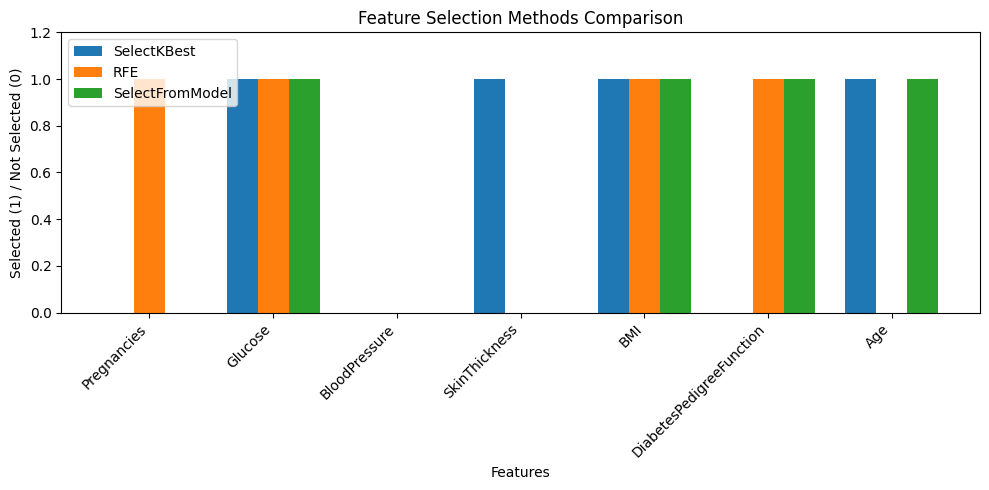

In [10]:
# Comparar qué atributos selecciona cada método
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'SelectKBest': selector_kbest.get_support(),
    'RFE': rfe.support_,
    'SelectFromModel': selector_model.get_support()
})

print('\nComparación de Métodos de Selección de Características:')
print(comparison_df.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(feature_names))
width = 0.25

ax.bar(x - width, selector_kbest.get_support().astype(int), width, label='SelectKBest')
ax.bar(x, rfe.support_.astype(int), width, label='RFE')
ax.bar(x + width, selector_model.get_support().astype(int), width, label='SelectFromModel')

ax.set_xlabel('Features')
ax.set_ylabel('Selected (1) / Not Selected (0)')
ax.set_title('Feature Selection Methods Comparison')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.2])

plt.tight_layout()
plt.show()

## Evaluar modelos con cada método de Feature Selection usando CV

Puntuaciones CV AUC para cada Método de Selección de Características:
RFE                           : 0.8318
No Feature Selection          : 0.8301
SelectFromModel               : 0.8270
SelectKBest                   : 0.8178


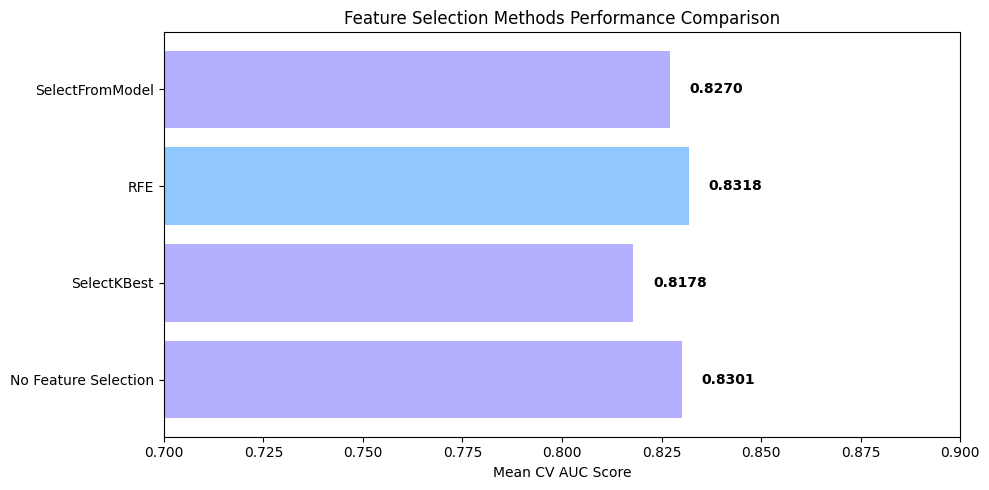

In [11]:
from sklearn.model_selection import cross_val_score

# Evaluar modelos con CV
results_fs = {}

# Sin feature selection
lr_none = LogisticRegression(max_iter=1000, random_state=42)
scores_none = cross_val_score(lr_none, X_train, y_train, cv=5, scoring='roc_auc')
results_fs['No Feature Selection'] = scores_none.mean()

# Con SelectKBest
lr_kbest = LogisticRegression(max_iter=1000, random_state=42)
scores_kbest = cross_val_score(lr_kbest, X_train_kbest, y_train, cv=5, scoring='roc_auc')
results_fs['SelectKBest'] = scores_kbest.mean()

# Con RFE
lr_rfe = LogisticRegression(max_iter=1000, random_state=42)
scores_rfe = cross_val_score(lr_rfe, X_train_rfe, y_train, cv=5, scoring='roc_auc')
results_fs['RFE'] = scores_rfe.mean()

# Con SelectFromModel
lr_sfm = LogisticRegression(max_iter=1000, random_state=42)
scores_sfm = cross_val_score(lr_sfm, X_train_sfm, y_train, cv=5, scoring='roc_auc')
results_fs['SelectFromModel'] = scores_sfm.mean()

print('Puntuaciones CV AUC para cada Método de Selección de Características:')
for method, score in sorted(results_fs.items(), key=lambda x: x[1], reverse=True):
    print(f'{method:30s}: {score:.4f}')

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
methods = list(results_fs.keys())
scores = list(results_fs.values())
colors_fs = ['#74b9ff' if s == max(scores) else '#a29bfe' for s in scores]

bars = ax.barh(methods, scores, color=colors_fs, alpha=0.8)
ax.set_xlabel('Mean CV AUC Score')
ax.set_title('Feature Selection Methods Performance Comparison')
ax.set_xlim([0.7, 0.9])

for i, (bar, score) in enumerate(zip(bars, scores)):
    ax.text(score + 0.005, i, f'{score:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
# PARTE 3: MODELOS CLÁSICOS CON CV Y FEATURE SELECTION

## Logistic Regression con CV

In [12]:
from sklearn.linear_model import LogisticRegressionCV

# LogisticRegressionCV automáticamente ajusta C con CV
lr_cv = LogisticRegressionCV(
    penalty='l2',
    scoring='roc_auc',
    solver='lbfgs',
    Cs=np.logspace(-4, 4, 20),
    cv=5,
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_cv.fit(X_train, y_train)

print('Resultados de LogisticRegressionCV:')
print(f'Mejor C: {lr_cv.C_[0]:.6f}')
print(f'AUC CV promedio: {lr_cv.scores_[1].mean():.4f}')

y_pred_lr = lr_cv.predict_proba(X_test)[:, 1]
print(f'Predicciones de test - Mín: {y_pred_lr.min():.4f}, Máx: {y_pred_lr.max():.4f}')

Resultados de LogisticRegressionCV:
Mejor C: 0.088587
AUC CV promedio: 0.8276
Predicciones de test - Mín: 0.0202, Máx: 0.9510


## Support Vector Machine (SVM) con CV y Feature Selection

In [13]:
from sklearn.svm import SVC

# Usar datos con SelectKBest
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': [0.001, 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    SVC(probability=True),
    param_grid=svm_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

svm_grid.fit(X_train_kbest, y_train)

print('Resultados de SVM con SelectKBest:')
print(f'Mejores parámetros: {svm_grid.best_params_}')
print(f'Mejor CV AUC: {svm_grid.best_score_:.4f}')

y_pred_svm = svm_grid.predict_proba(X_test_kbest)[:, 1]
print(f'Test predictions - Min: {y_pred_svm.min():.4f}, Max: {y_pred_svm.max():.4f}')

Resultados de SVM con SelectKBest:
Mejores parámetros: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Mejor CV AUC: 0.8232
Test predictions - Min: 0.0227, Max: 0.9726


## Random Forest con CV

In [14]:
# Usar datos con RFE
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [2, 4, 8]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train_rfe, y_train)

print('Resultados de Random Forest con RFE:')
print(f'Best parameters: {rf_grid.best_params_}')
print(f'Best CV AUC: {rf_grid.best_score_:.4f}')

y_pred_rf = rf_grid.predict_proba(X_test_rfe)[:, 1]
print(f'Test predictions - Min: {y_pred_rf.min():.4f}, Max: {y_pred_rf.max():.4f}')

Resultados de Random Forest con RFE:
Best parameters: {'max_depth': 5, 'min_samples_leaf': 8, 'n_estimators': 50}
Best CV AUC: 0.8206
Test predictions - Min: 0.0025, Max: 0.9502


## Gradient Boosting con CV

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

# Usar datos con SelectFromModel
gbm_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

gbm_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gbm_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

gbm_grid.fit(X_train_sfm, y_train)

print('Resultados de Gradient Boosting con SelectFromModel:')
print(f'Best parameters: {gbm_grid.best_params_}')
print(f'Best CV AUC: {gbm_grid.best_score_:.4f}')

y_pred_gbm = gbm_grid.predict_proba(X_test_sfm)[:, 1]
print(f'Test predictions - Min: {y_pred_gbm.min():.4f}, Max: {y_pred_gbm.max():.4f}')

Resultados de Gradient Boosting con SelectFromModel:
Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best CV AUC: 0.8237
Test predictions - Min: 0.0804, Max: 0.8546


---
# PARTE 4: PYCARET - AUTOMATED MACHINE LEARNING

## ¿Qué es PyCaret?
PyCaret es una librería de ML automatizada que:
- Realiza preprocesamiento automático
- Tunea automáticamente hyperparameters usando CV
- Prueba múltiples algoritmos
- Genera reportes y visualizaciones


In [16]:

from pycaret.classification import setup, compare_models,pull,plot_model
from pycaret.classification import *
pycaret_available = True

## PyCaret: Setup y Comparación automática de modelos

In [17]:
# Preparar datos
df_train_pycaret = dset_trn.copy()
df_train_pycaret = df_train_pycaret.drop(columns=['Id'])

print('\nSETUP: Preprocesamiento automático')

# Setup realiza preprocesamiento
exp1 = setup(
    data=df_train_pycaret,
    target='Outcome',
    session_id=42,
    verbose=False,
    #feature_selection = True, ## usar este argumento para usar la seleccion clasica (foward) de argumentos
    remove_multicollinearity = True, multicollinearity_threshold = 0.3    #usar este argumento para no permitir multicollinearity
)
print('Configuración completada')


SETUP: Preprocesamiento automático
Configuración completada


In [18]:
### Imprimir data inicial
exp1.train

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
514,1,83.0,68.0,NaN,18.200001,0.624,27,0
380,0,119.0,66.0,27.0,38.799999,0.259,22,0
151,10,139.0,80.0,NaN,27.100000,1.441,57,0
526,2,99.0,70.0,16.0,20.400000,0.235,27,0
524,7,114.0,76.0,17.0,23.799999,0.466,31,0
...,...,...,...,...,...,...,...,...
96,6,165.0,68.0,26.0,33.599998,0.631,49,0
7,2,74.0,NaN,NaN,NaN,0.102,22,0
324,0,180.0,90.0,26.0,36.500000,0.314,35,1
44,1,84.0,64.0,23.0,36.900002,0.471,28,0


In [19]:
### Imprimir data posterior a la selección de atributos
exp1.train_transformed

,Glucose,BMI,DiabetesPedigreeFunction,Outcome
514,83.0,18.200001,0.624,0
380,119.0,38.799999,0.259,0
151,139.0,27.100000,1.441,0
526,99.0,20.400000,0.235,0
524,114.0,23.799999,0.466,0
...,...,...,...,...
96,165.0,33.599998,0.631,0
7,74.0,32.346069,0.102,0
324,180.0,36.500000,0.314,1
44,84.0,36.900002,0.471,0


## PyCaret: Comparar múltiples modelos automáticamente

In [20]:
print('\nCOMPARAR MODELOS: Probando múltiples algoritmos con CV')
best_model_pycaret = compare_models(
        fold=5,
        sort='AUC')
print(f'\nMejor modelo: {type(best_model_pycaret).__name__}')


COMPARAR MODELOS: Probando múltiples algoritmos con CV


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7580,0.8348,0.5564,0.6974,0.6144,0.4428,0.4510,0.0140
lda,Linear Discriminant Analysis,0.7526,0.8345,0.5564,0.6857,0.6090,0.4325,0.4404,0.0140
lr,Logistic Regression,0.7580,0.8319,0.5564,0.6982,0.6147,0.4430,0.4513,0.3540
nb,Naive Bayes,0.7525,0.8173,0.5627,0.6774,0.6105,0.4331,0.4389,0.2680
qda,Quadratic Discriminant Analysis,0.7287,0.8110,0.5330,0.6380,0.5756,0.3803,0.3862,0.0140
et,Extra Trees Classifier,0.7208,0.7973,0.5410,0.6158,0.5714,0.3675,0.3712,0.0540
gbc,Gradient Boosting Classifier,0.7127,0.7853,0.5262,0.6102,0.5625,0.3510,0.3545,0.0420
rf,Random Forest Classifier,0.7181,0.7800,0.5641,0.6124,0.5841,0.3720,0.3748,0.0660
knn,K Neighbors Classifier,0.7208,0.7779,0.5863,0.6112,0.5960,0.3832,0.3852,0.3560
ada,Ada Boost Classifier,0.7340,0.7713,0.5641,0.6454,0.6007,0.4025,0.4055,0.0360



Mejor modelo: RidgeClassifier


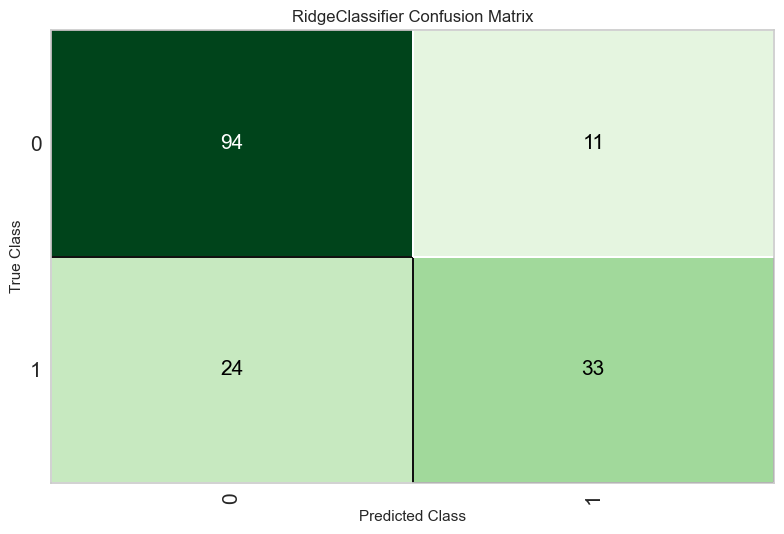

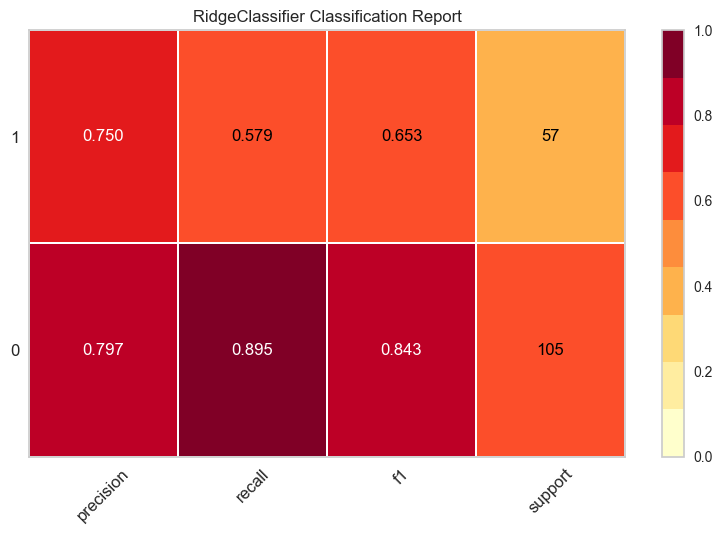

In [21]:
plot_model(best_model_pycaret, plot = 'confusion_matrix')
plot_model(best_model_pycaret, plot = 'class_report')

## PyCaret: Tuning del mejor modelo

In [22]:
print('\nAJUSTAR MODELO: Ajuste fino con Optimización Bayesiana')
tuned_model = tune_model(
        best_model_pycaret,
        optimize='AUC',
        fold=5,
        n_iter=10)
print('Ajuste completado')


AJUSTAR MODELO: Ajuste fino con Optimización Bayesiana


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7632,0.8322,0.5185,0.7368,0.6087,0.4462,0.4603
1,0.8267,0.8948,0.7308,0.7600,0.7451,0.6139,0.6141
2,0.7067,0.8359,0.3462,0.6429,0.4500,0.2738,0.2982
3,0.7200,0.7948,0.5556,0.6250,0.5882,0.3772,0.3787
4,0.7467,0.8233,0.5926,0.6667,0.6275,0.4365,0.4383
Mean,0.7526,0.8362,0.5487,0.6863,0.6039,0.4295,0.4379
Std,0.0420,0.0327,0.1241,0.0529,0.0943,0.1107,0.1045


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Ajuste completado


### Usar decision trees

In [23]:
dt = create_model('dt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6842,0.6677,0.6154,0.5333,0.5714,0.3234,0.3255
1,0.5526,0.5123,0.3846,0.3571,0.3704,0.0242,0.0242
2,0.6842,0.6492,0.5385,0.5385,0.5385,0.2985,0.2985
3,0.6579,0.6250,0.5000,0.5385,0.5185,0.2538,0.2542
4,0.7105,0.6815,0.5714,0.6154,0.5926,0.3686,0.3692
5,0.6579,0.6399,0.5714,0.5333,0.5517,0.2757,0.2761
6,0.6757,0.6619,0.6154,0.5333,0.5714,0.3127,0.3148
7,0.6486,0.5881,0.3846,0.5000,0.4348,0.1861,0.1895
8,0.7027,0.6651,0.5385,0.5833,0.5600,0.3361,0.3367


In [24]:
dt_grid = {'max_depth' : [None, 2, 4, 6, 8, 10, 12]}

# tune model with custom grid and metric = F1
tuned_dt = tune_model(dt, custom_grid = dt_grid, optimize = 'F1')

##### también se usa automaticamente como:
#tuned_dt = tune_model(dt)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8158,0.7938,0.7692,0.7143,0.7407,0.5982,0.5992
1,0.7368,0.6985,0.4615,0.6667,0.5455,0.3688,0.3811
2,0.7368,0.7246,0.6154,0.6154,0.6154,0.4154,0.4154
3,0.7895,0.7679,0.5714,0.8000,0.6667,0.5190,0.5347
4,0.6842,0.6935,0.2857,0.6667,0.4000,0.2297,0.2677
5,0.7105,0.7054,0.5714,0.6154,0.5926,0.3686,0.3692
6,0.7027,0.7019,0.5385,0.5833,0.5600,0.3361,0.3367
7,0.7027,0.7500,0.6154,0.5714,0.5926,0.3591,0.3597
8,0.7568,0.7500,0.4615,0.7500,0.5714,0.4148,0.4386


Fitting 10 folds for each of 7 candidates, totalling 70 fits


In [25]:
# ensamble con bagging
ensemble_model(dt, method = 'Bagging')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7632,0.7846,0.6923,0.6429,0.6667,0.4834,0.4842
1,0.7105,0.6108,0.3077,0.6667,0.4211,0.2615,0.2962
2,0.6053,0.7062,0.3077,0.4000,0.3478,0.0717,0.0729
3,0.7895,0.8542,0.7143,0.7143,0.7143,0.5476,0.5476
4,0.7632,0.8110,0.4286,0.8571,0.5714,0.4319,0.4814
5,0.6579,0.7470,0.4286,0.5455,0.4800,0.2305,0.2343
6,0.6757,0.7276,0.5385,0.5385,0.5385,0.2885,0.2885
7,0.7027,0.7821,0.3846,0.6250,0.4762,0.2847,0.3011
8,0.6486,0.7131,0.2308,0.5000,0.3158,0.1207,0.1370


BaggingClassifier(bootstrap=True, bootstrap_features=False,
                  estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                                   class_weight=None,
                                                   criterion='gini',
                                                   max_depth=None,
                                                   max_features=None,
                                                   max_leaf_nodes=None,
                                                   min_impurity_decrease=0.0,
                                                   min_samples_leaf=1,
                                                   min_samples_split=2,
                                                   min_weight_fraction_leaf=0.0,
                                                   monotonic_cst=None,
                                                   random_state=42,
                                                   splitter='best'),
                  max_features=1.0, max_samples=1.0, n_estimators=10,
                  n_jobs=None, oob_score=False, random_state=42, verbose=0,
                  warm_start=False)

In [26]:
# ensamble con boosting
ensemble_model(dt, method = 'Boosting')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6842,0.6677,0.6154,0.5333,0.5714,0.3234,0.3255
1,0.5526,0.5123,0.3846,0.3571,0.3704,0.0242,0.0242
2,0.6316,0.6092,0.5385,0.4667,0.5000,0.2107,0.2120
3,0.6842,0.6607,0.5714,0.5714,0.5714,0.3214,0.3214
4,0.7105,0.6964,0.6429,0.6000,0.6207,0.3871,0.3877
5,0.6053,0.5833,0.5000,0.4667,0.4828,0.1642,0.1645
6,0.6757,0.6619,0.6154,0.5333,0.5714,0.3127,0.3148
7,0.6486,0.5881,0.3846,0.5000,0.4348,0.1861,0.1895
8,0.6757,0.6266,0.4615,0.5455,0.5000,0.2625,0.2645


AdaBoostClassifier(algorithm='SAMME.R',
                   estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                                    class_weight=None,
                                                    criterion='gini',
                                                    max_depth=None,
                                                    max_features=None,
                                                    max_leaf_nodes=None,
                                                    min_impurity_decrease=0.0,
                                                    min_samples_leaf=1,
                                                    min_samples_split=2,
                                                    min_weight_fraction_leaf=0.0,
                                                    monotonic_cst=None,
                                                    random_state=42,
                                                    splitter='best'),
                   learning_rate=1.0, n_estimators=10, random_state=42)

In [27]:
# ensamble con stack
best_recall_models_top3 = compare_models(sort = 'Recall', n_select = 3)
stack=stack_models(best_recall_models_top3)
stack

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.7314,0.7819,0.5868,0.6370,0.6056,0.4037,0.4087,0.0150
nb,Naive Bayes,0.7580,0.8316,0.5648,0.7091,0.6207,0.4477,0.4600,0.0090
lightgbm,Light Gradient Boosting Machine,0.7125,0.7640,0.5637,0.6079,0.5785,0.3625,0.3678,0.0320
gbc,Gradient Boosting Classifier,0.7179,0.7994,0.5571,0.6187,0.5781,0.3697,0.3758,0.0290
lda,Linear Discriminant Analysis,0.7498,0.8369,0.5571,0.6971,0.6076,0.4294,0.4428,0.0100
ada,Ada Boost Classifier,0.7233,0.8134,0.5566,0.6452,0.5854,0.3811,0.3917,0.0240
lr,Logistic Regression,0.7525,0.8390,0.5495,0.7033,0.6069,0.4321,0.4454,0.0110
ridge,Ridge Classifier,0.7550,0.8378,0.5495,0.7162,0.6094,0.4375,0.4537,0.0080
et,Extra Trees Classifier,0.7260,0.7846,0.5489,0.6404,0.5794,0.3813,0.3913,0.0360
qda,Quadratic Discriminant Analysis,0.7314,0.8125,0.5357,0.6603,0.5790,0.3882,0.4004,0.0080


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7105,0.7692,0.5385,0.5833,0.5600,0.3448,0.3454
1,0.7632,0.8062,0.3846,0.8333,0.5263,0.3958,0.4484
2,0.7632,0.8892,0.6154,0.6667,0.6400,0.4639,0.4648
3,0.7895,0.8929,0.5714,0.8000,0.6667,0.5190,0.5347
4,0.7632,0.8482,0.5000,0.7778,0.6087,0.4502,0.4728
5,0.7105,0.8095,0.4286,0.6667,0.5217,0.3280,0.3444
6,0.7568,0.7436,0.5385,0.7000,0.6087,0.4365,0.4445
7,0.7568,0.7853,0.6154,0.6667,0.6400,0.4568,0.4576
8,0.7568,0.8558,0.3846,0.8333,0.5263,0.3912,0.4442


StackingClassifier(cv=5,
                   estimators=[('K Neighbors Classifier',
                                KNeighborsClassifier(algorithm='auto',
                                                     leaf_size=30,
                                                     metric='minkowski',
                                                     metric_params=None,
                                                     n_jobs=-1, n_neighbors=5,
                                                     p=2, weights='uniform')),
                               ('Naive Bayes',
                                GaussianNB(priors=None, var_smoothing=1e-09)),
                               ('Light Gradient Boosting Machine',
                                LGBMClassifier(boosting_type='gbdt',
                                               class_weight=None,
                                               colsampl...
                                               subsample_for_bin=200000,
                                               subsample_freq=0))],
                   final_estimator=LogisticRegression(C=1.0, class_weight=None,
                                                      dual=False,
                                                      fit_intercept=True,
                                                      intercept_scaling=1,
                                                      l1_ratio=None,
                                                      max_iter=1000,
                                                      multi_class='auto',
                                                      n_jobs=None, penalty='l2',
                                                      random_state=42,
                                                      solver='lbfgs',
                                                      tol=0.0001, verbose=0,
                                                      warm_start=False),
                   n_jobs=-1, passthrough=False, stack_method='auto',
                   verbose=0)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7368,0.7692,0.6923,0.6000,0.6429,0.4362,0.4390
1,0.6842,0.6646,0.4615,0.5455,0.5000,0.2716,0.2736
2,0.6842,0.7292,0.6154,0.5333,0.5714,0.3234,0.3255
3,0.7368,0.8065,0.6429,0.6429,0.6429,0.4345,0.4345
4,0.8158,0.8899,0.5714,0.8889,0.6957,0.5723,0.6011
5,0.7105,0.8065,0.5000,0.6364,0.5600,0.3489,0.3545
6,0.6486,0.6923,0.4615,0.5000,0.4800,0.2153,0.2157
7,0.6757,0.7532,0.6154,0.5333,0.5714,0.3127,0.3148
8,0.6757,0.7724,0.3846,0.5556,0.4545,0.2345,0.2425


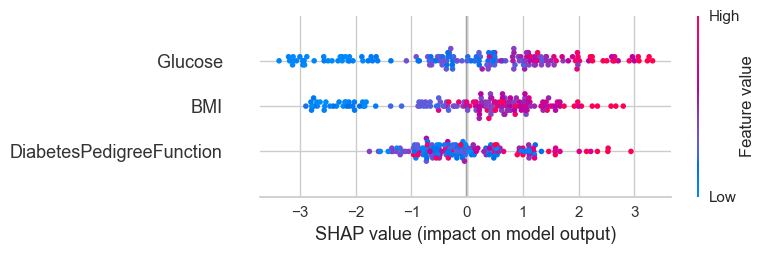

In [28]:
## Iterpretabilidad del modelo boosting con Shap values!!!
lightgbm = create_model('lightgbm')
interpret_model(lightgbm, plot = 'summary')

## PyCaret: Finalizando y predicciones: Ejercicio
Use df_test_pycaret y desarrolle la predicción de este nuevo conjunto de datos. Compare sus resultados con prima_solution.csv. Desarrolle el mismo ejercicio con diferentes modelos y ensambles hasta obtener el mejor modelo!!


In [29]:
df_test_pycaret = dset_tst.copy()
df_test_pycaret = df_test_pycaret.drop(columns='Id')

In [30]:
print('\nFINALIZAR MODELO: Entrenamiento con todos los datos')
final_model = finalize_model(tuned_model)


print('Realizando predicciones en el conjunto de prueba...')
predictions = predict_model(final_model, data = df_test_pycaret)
predictions.head()



FINALIZAR MODELO: Entrenamiento con todos los datos
Realizando predicciones en el conjunto de prueba...


,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,prediction_label
0,1,85.0,66.0,29.0,26.600000,0.351,31,0
1,0,137.0,40.0,35.0,43.099998,2.288,33,1
2,5,116.0,74.0,NaN,25.600000,0.201,30,0
3,10,168.0,74.0,NaN,38.000000,0.537,34,1
4,1,103.0,30.0,38.0,43.299999,0.183,33,0
